### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P77 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

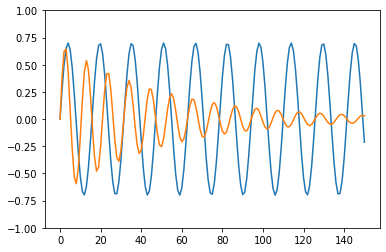

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 4

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

77

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0018364115479811952   3.917304277420044 sec       
199: 0.0006715438426535428   6.083544731140137 sec       
299: 0.0008002905526685837   8.14246129989624 sec        
399: 0.0003701214004104578   10.137797594070435 sec       
499: 0.0003083535756981726   12.187755346298218 sec       
599: 0.0002639978583014356   14.165889263153076 sec       
699: 0.00023711274464216826   16.234418392181396 sec      
799: 0.00022001044384379055   18.249011278152466 sec      
899: 0.00020486903899064025   20.290563583374023 sec      
999: 0.00019080707114419197   22.30979323387146 sec       
1099: 0.00017732564978320772   24.428834676742554 sec      
1199: 0.0001618599634084513   26.710846662521362 sec       
1299: 0.00014577972929767118   28.78056836128235 sec       
1399: 0.0001304721134353264   31.109628200531006 sec       
1499: 0.0001150098963468251   33.53423762321472 sec        
1599: 0.00021052712698575393   35.676275968551636 sec      
1699: 0.0001483248520074757   37.89

26499: 0.00018926595713127247   345.5883572101593 sec       
26599: 0.00018478077762360722   346.7086021900177 sec       
26699: 0.00018348609198702874   347.8212010860443 sec       
26799: 0.00017599785499160597   348.9742658138275 sec       
26899: 0.00017174936255334202   350.10909390449524 sec      
26999: 0.00016781937154698408   351.29406452178955 sec      
27099: 0.00016429263630843405   352.4638764858246 sec       
27199: 0.00016116269197028328   353.62887930870056 sec      
27299: 0.00015862209220677704   354.7818064689636 sec       
27399: 0.00015579512169962444   355.9522044658661 sec       
27499: 0.0001531592473526903   357.06310081481934 sec       
27599: 0.0001504929135575262   358.26201272010803 sec       
27699: 0.00014773704148067434   359.3977518081665 sec       
27799: 0.00014477390066874082   360.5077474117279 sec       
27899: 0.0001412039293033869   361.6945970058441 sec        
27999: 0.00013704820627062175   362.8821234703064 sec       
28099: 0.000131700952287

52699: 0.00033718466057809   653.0570352077484 sec         
52799: 0.00018811350615241084   654.3417782783508 sec      
52899: 0.00016020021412356024   655.6585247516632 sec      
52999: 0.000455677703783442   656.8494403362274 sec        
53099: 0.0002928979588601155   657.9883570671082 sec       
53199: 0.00023985367099792923   659.208359003067 sec       
learning rate: 0.05
53299: 0.01681921936597572   660.4868764877319 sec         
53399: 0.0148546008840999   661.794412612915 sec         
53499: 0.013239642419374028   663.0818381309509 sec      
learning rate: 0.025
53599: 0.02420559433848993   664.3294093608856 sec         
53699: 0.020808515136163785   665.605991601944 sec       
53799: 0.0197189299371666   666.8862068653107 sec        
learning rate: 0.0125
53899: 0.00016146358177991226   668.1539590358734 sec      
53999: 0.00015132641465353242   669.4166376590729 sec      
54099: 0.00014563410721028355   671.3103857040405 sec      
54199: 0.00013975289767202229   672.599118471

79499: 0.00029827385208123017   1018.2885060310364 sec      
79599: 0.00025649236475578486   1020.0003638267517 sec      
79699: 0.00022925918319383718   1021.7247321605682 sec      
79799: 0.00021205346904734212   1023.3972249031067 sec      
79899: 0.00019804630443957948   1025.1064417362213 sec      
79999: 0.00018473815625869388   1026.838058233261 sec       
80099: 0.00017294197229058149   1028.385585784912 sec       
80199: 0.00016333037048032865   1029.8478255271912 sec      
80299: 0.0001552531371223684   1031.497174024582 sec        
80399: 0.00014808161783329098   1033.1446027755737 sec      
80499: 0.00014141922659168476   1034.908107995987 sec       
80599: 0.00013507787369064985   1036.515972852707 sec       
80699: 0.00012903170388338196   1037.9743747711182 sec      
80799: 0.00012359780023368528   1039.4845571517944 sec      
80899: 0.00011837006727476334   1040.9232749938965 sec      
80999: 0.00011344970216341741   1042.450867652893 sec       
81099: 0.000108790065556

105599: 0.00014617603352568478   1382.1958351135254 sec      
105699: 0.0001369785386812506   1383.6981852054596 sec       
105799: 0.00012807959538502437   1385.1075043678284 sec      
105899: 0.00012010023127417309   1386.6057786941528 sec      
105999: 0.00011327190437382884   1388.0237650871277 sec      
106099: 0.00010646845333341223   1389.4213149547577 sec      
106199: 9.849088750938993e-05   1390.7694866657257 sec       
106299: 8.895901666668035e-05   1392.1763844490051 sec      
106399: 0.00014937471732926353   1393.542034626007 sec       
106499: 0.00011732095643804805   1394.9412295818329 sec      
106599: 0.0001070908814513787   1396.2928767204285 sec       
learning rate: 0.05
106699: 0.0001269316697508802   1397.7436437606812 sec       
106799: 0.0001070251770925457   1399.141347169876 sec        
106899: 9.368566997623773e-05   1400.5793845653534 sec       
106999: 0.00016614167599659265   1402.042973279953 sec       
107099: 8.117931077382814e-05   1403.564136505127 s

...

260699: 5.5718517777976694e-05   3504.328015089035 sec       
260799: 5.4570907517969e-05   3505.604377269745 sec          
260899: 5.153346250599047e-05   3506.8007690906525 sec       
260999: 4.941263994150174e-05   3508.05424952507 sec         
261099: 4.882351637215299e-05   3509.3068301677704 sec       
261199: 4.6784828115620014e-05   3510.615085840225 sec       
261299: 5.793040566210129e-05   3511.9701385498047 sec       
261399: 4.485134933205552e-05   3513.2092876434326 sec       
261499: 4.3269679892737015e-05   3514.3868622779846 sec      
261599: 4.197183500698173e-05   3515.6693313121796 sec       
261699: 4.1934308429863405e-05   3516.898624420166 sec       
261799: 4.0409557903142133e-05   3518.0853855609894 sec      
261899: 4.008608347592898e-05   3519.332018852234 sec        
261999: 3.990880926021843e-05   3520.541476249695 sec        
262099: 3.9709083993651934e-05   3521.936788082123 sec       
learning rate: 0.2
262199: 0.0006941951775124533   3523.2123777866364 

286599: 7.651205734816715e-05   3818.616420507431 sec        
286699: 7.014045500345881e-05   3819.8628735542297 sec      
286799: 0.14005297335998618   3821.133022069931 sec          
286899: 0.030656641346059353   3822.368350982666 sec       
286999: 0.025669989554631928   3823.5565853118896 sec      
learning rate: 0.1
287099: 0.07818678164423112   3824.82989859581 sec        
287199: 0.07547380207631808   3826.0024979114532 sec      
287299: 0.07451275767118867   3827.203412294388 sec       
learning rate: 0.05
287399: 0.05308642885567548   3828.4509608745575 sec       
287499: 0.057365707946670244   3829.5949025154114 sec      
287599: 0.09316208613004687   3830.8083395957947 sec       
287699: 0.11935234613924305   3831.9424216747284 sec      
learning rate: 0.025
287799: 0.07084686734249764   3833.1413979530334 sec       
learning rate: 0.0125
287899: 0.004448740296365653   3834.3363332748413 sec       
287999: 0.001719830931089062   3835.6856780052185 sec       
288099: 0.00101

312599: 6.330823137278216e-05   4096.146534442902 sec       
312699: 6.258250610543564e-05   4097.133943557739 sec       
312799: 6.192489790498154e-05   4098.170491218567 sec       
312899: 0.000146463476218863   4099.1249532699585 sec        
312999: 6.341012511924758e-05   4100.482983827591 sec        
313099: 6.130404388582573e-05   4101.6957631111145 sec      
313199: 6.028942359007567e-05   4102.774004459381 sec        
313299: 5.948112184386707e-05   4103.765414476395 sec        
313399: 5.8757271988736695e-05   4104.863930225372 sec       
313499: 0.0001648280524161746   4105.881852149963 sec        
313599: 5.9386748559285274e-05   4106.885613203049 sec      
313699: 5.775272934723394e-05   4107.86580657959 sec         
313799: 5.6790193348105406e-05   4108.848508834839 sec       
313899: 5.6047910131086294e-05   4109.94306063652 sec        
313999: 5.803079533866158e-05   4111.03112077713 sec         
314099: 5.626081508486496e-05   4112.175955295563 sec        
314199: 0.000

338499: 0.0002156089439361064   4360.6027135849 sec          
338599: 0.0002080921454973086   4361.763903617859 sec        
338699: 0.00020117465590214383   4362.736827850342 sec       
338799: 0.00019482831876362148   4363.7445657253265 sec      
338899: 0.000846707826026687   4364.752750635147 sec         
338999: 0.00018456299957161373   4365.738488197327 sec       
339099: 0.00017870779907180266   4366.750562667847 sec       
339199: 0.00017262189478824686   4367.786550760269 sec       
339299: 0.00016392666763984098   4368.780764102936 sec       
339399: 0.0001638482993363527   4369.7511947155 sec          
339499: 0.0001581583040076142   4370.8444101810455 sec       
339599: 0.0004114641317822894   4371.827173948288 sec        
339699: 0.00046661167165841825   4372.802200317383 sec       
339799: 0.00016385297993470633   4373.8045427799225 sec      
learning rate: 0.05
339899: 0.0003746798111489305   4374.807616710663 sec        
339999: 0.00017142485524994616   4375.780156373978

364399: 7.978441505459877e-05   4623.317123174667 sec       
364499: 7.522859604931775e-05   4624.281631708145 sec       
364599: 0.00016823237616250272   4625.28161239624 sec        
364699: 0.00013165003479272578   4626.23531126976 sec        
364799: 0.00011547439533012226   4627.293516874313 sec       
learning rate: 0.05
364899: 9.108253204012247e-05   4628.348157405853 sec       
364999: 7.695231931765992e-05   4629.387850761414 sec       
365099: 7.12764788599348e-05   4630.403741121292 sec        
365199: 6.75789208908808e-05   4631.363086223602 sec        
365299: 6.489581109550286e-05   4632.429694652557 sec       
365399: 6.269189745334645e-05   4633.411947488785 sec       
365499: 6.0848919239953014e-05   4634.372532367706 sec      
365599: 6.415519957235946e-05   4635.35973405838 sec         
365699: 6.684128620396693e-05   4636.397697687149 sec        
365799: 5.751091294921079e-05   4637.441749572754 sec        
365899: 5.643706394221644e-05   4638.453476905823 sec      

In [23]:
minLoss

Array(3.41975801e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

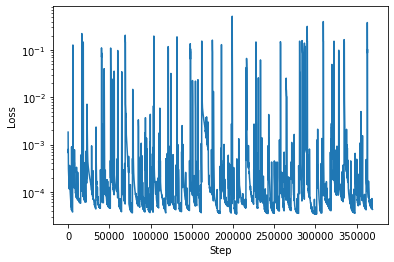

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

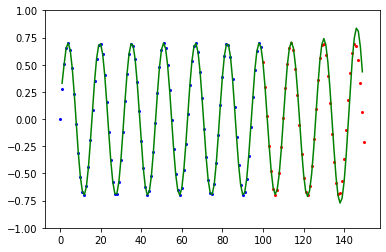

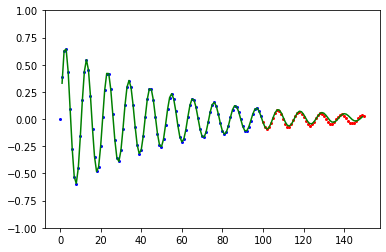

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

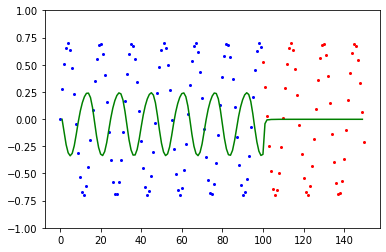

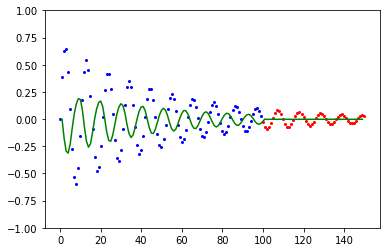

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[204700,
 Array(3.42291566e-05, dtype=float64),
 Array(0.00079623, dtype=float64),
 [((Array([[ 1.54948054,  0.30460184, -6.1500648 ,  0.23963202]], dtype=float64),
    Array([[-1.2765677 , -3.31104999,  0.4238241 , -0.55045286],
           [ 3.36557727,  1.46915191,  2.54821999,  3.68971607],
           [-1.93972353, -1.57489347, -0.08847973, -1.25962347],
           [ 5.47925589,  2.38574865, -4.89585069,  2.34153571]],      dtype=float64),
    Array([-2.68621647, -1.05256503,  4.20737952, -3.26421402], dtype=float64)),
   (Array([[-0.18048158, -0.53968134, -3.44569494,  0.33188017]], dtype=float64),
    Array([[-0.76808032, -0.27513988,  5.83907036, -0.74485081],
           [-1.5863091 ,  0.3527497 ,  2.56803838,  2.05735471],
           [ 2.50591219, -1.71142305,  0.42862937,  3.04813916],
           [-0.4548784 , -0.10691684, -2.33466076,  1.44701055]],      dtype=float64),
    Array([ 0.90100319,  1.80818533, -1.34459643, -1.19530367], dtype=float64)),
   (Array([[-2.9541103 ,  2

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

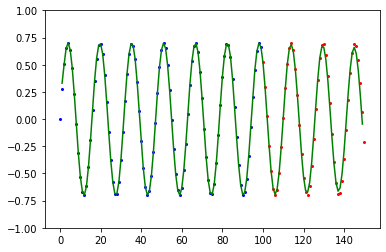

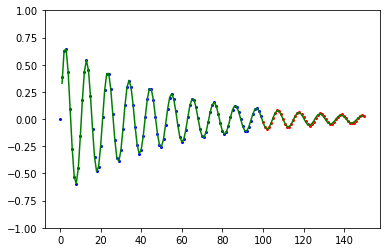

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [204700, Array(3.42291566e-05, dtype=float64), Array(0.00079623, dtype=float64)]
5500 3.747712160103885e-05 0.0062635315027558544


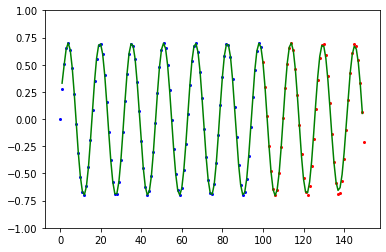

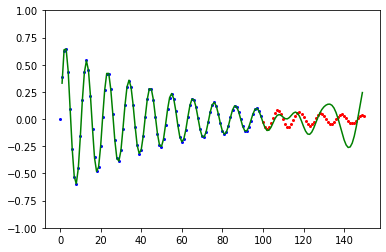

15300 5.794619999329759e-05 0.21909569586310254


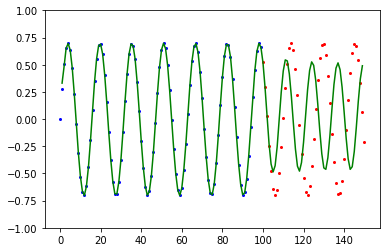

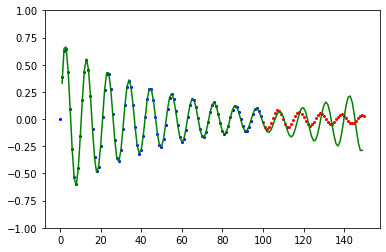

21900 6.106929447740121e-05 0.0014083583486144712


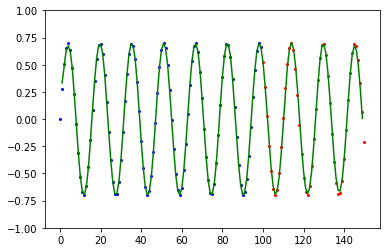

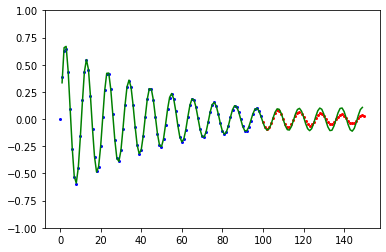

33700 4.35824679091101e-05 0.6754604289752717


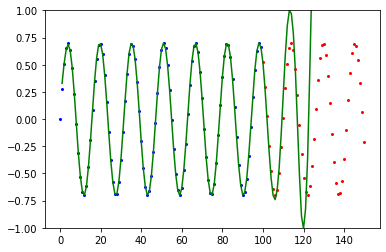

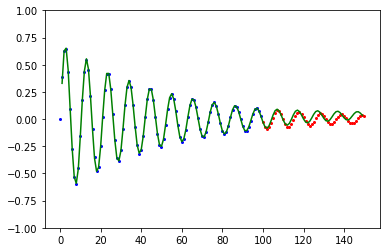

39200 4.5082399938477985e-05 0.10935826774399124


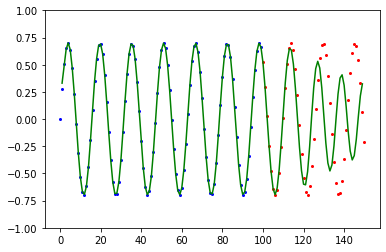

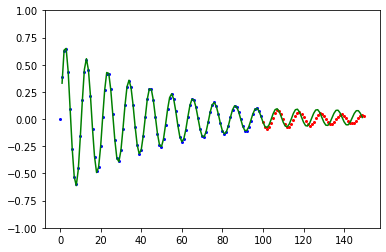

42900 5.891430774832073e-05 0.07043021195910437


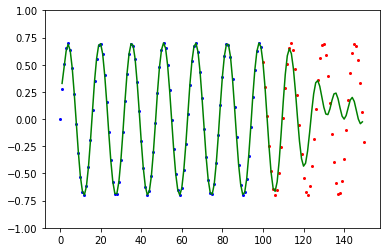

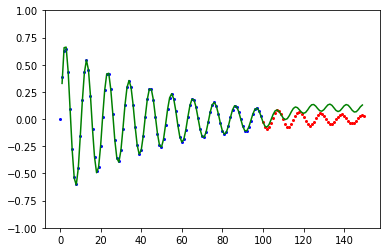

51300 4.531574389896869e-05 0.25703041219150746


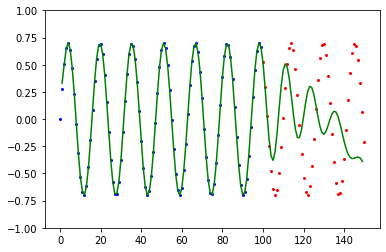

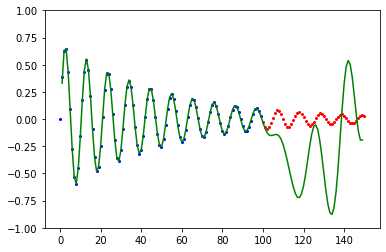

59100 0.00010168868394336166 0.1412466424930164


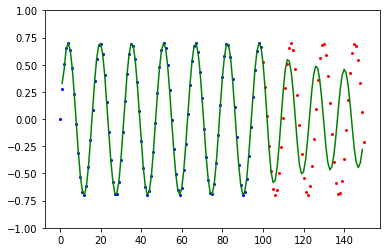

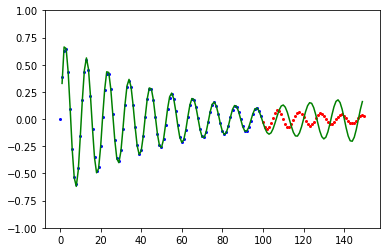

64900 3.801179122691669e-05 0.0014938454241327148


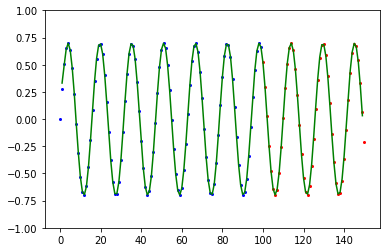

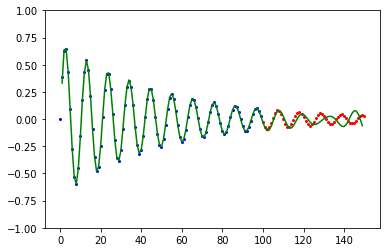

78100 3.612692688419664e-05 0.0015630051649202018


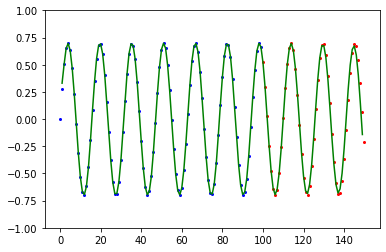

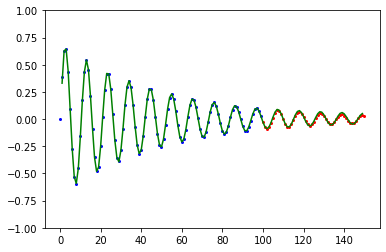

87000 4.7123115352509916e-05 0.10165841880266051


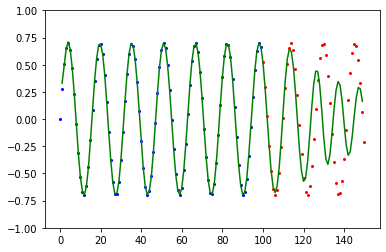

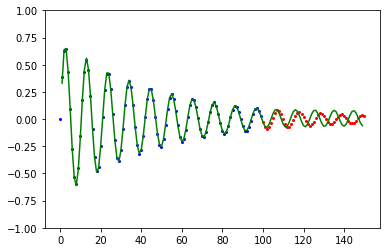

93400 3.7750148356062864e-05 0.21629085193059933


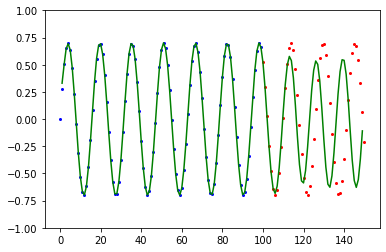

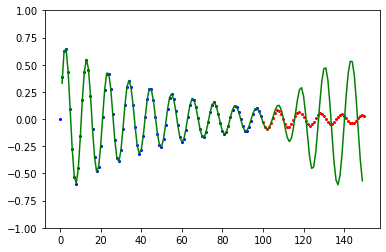

99400 3.644412193439049e-05 0.021053549510533988


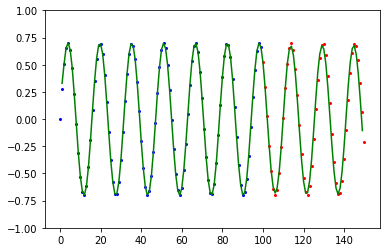

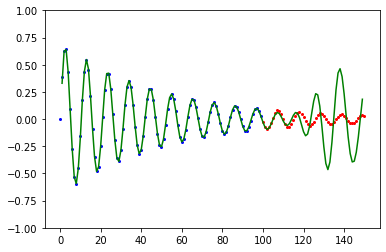

103200 3.711462210331527e-05 0.0015785860035059298


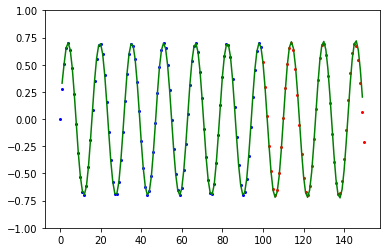

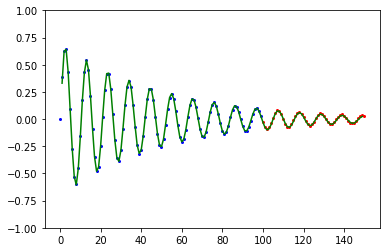

109900 4.5661987682440604e-05 0.08124829941607735


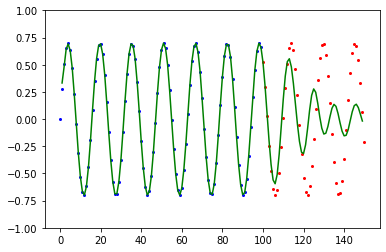

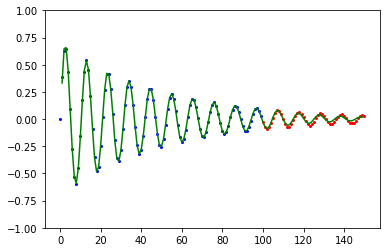

118600 3.5970563454949876e-05 0.07106048480035869


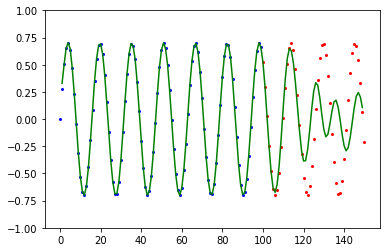

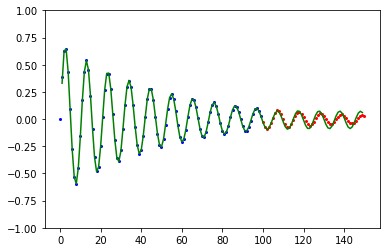

123800 5.220615302535083e-05 0.37390932667536597


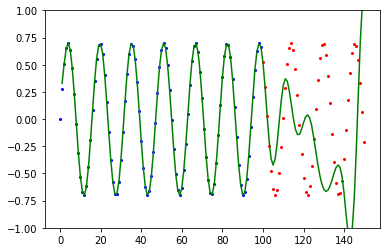

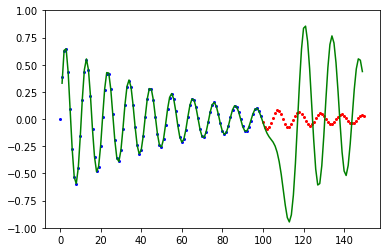

130700 4.192390442673683e-05 0.0339604342971955


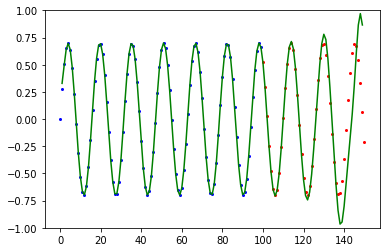

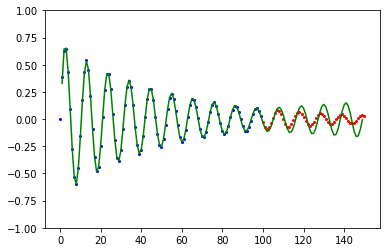

137700 3.840040629040847e-05 0.09992206812968459


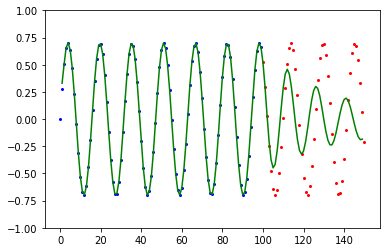

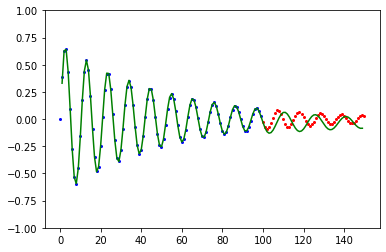

147300 4.03260816911596e-05 0.2669812208958285


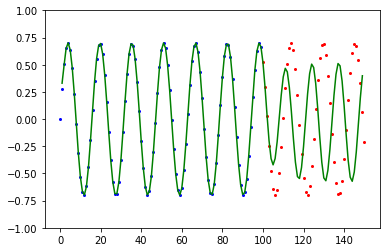

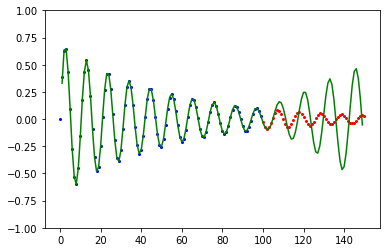

156200 5.1343872520477526e-05 0.26936327623472245


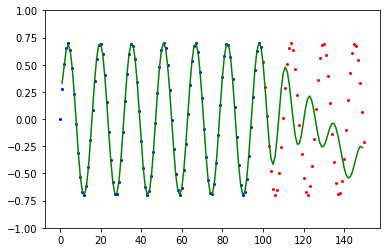

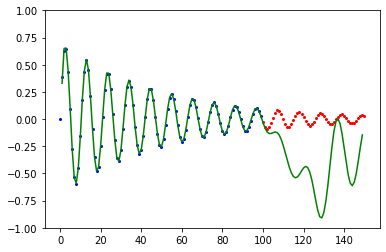

161600 3.624724480403767e-05 0.270989747070424


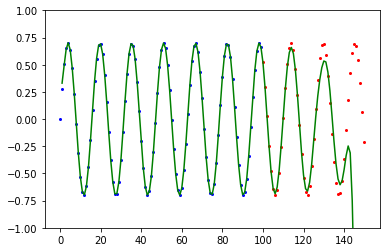

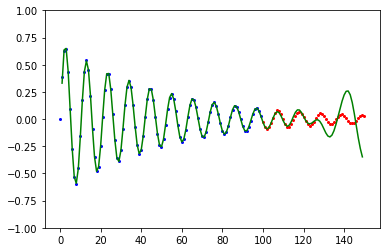

173900 9.577438737653746e-05 0.06356775250237555


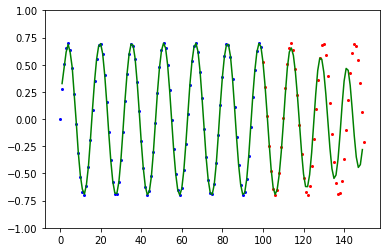

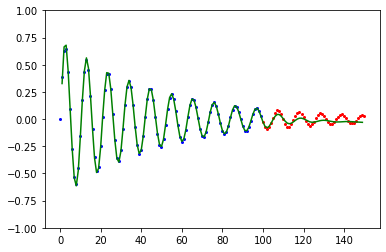

184400 3.5099356051604924e-05 0.03057822422712981


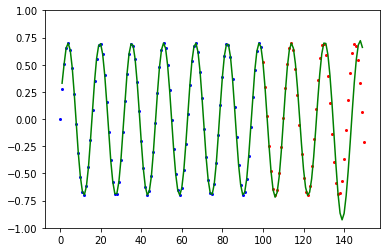

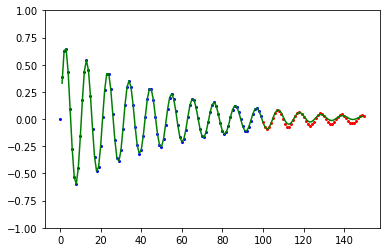

194300 4.894016639449649e-05 0.1343954097723269


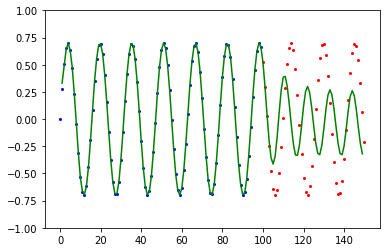

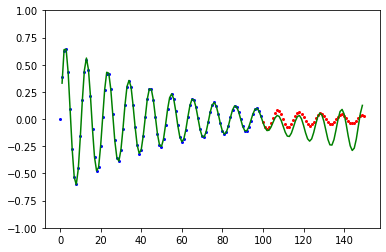

197900 3.5618654065053796e-05 0.09028050454385143


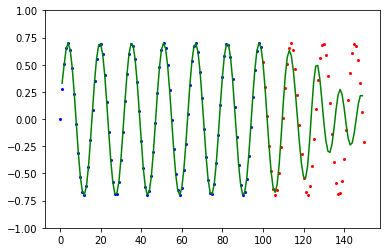

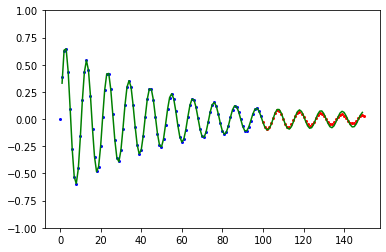

204700 3.422915657941242e-05 0.0007962293517817272


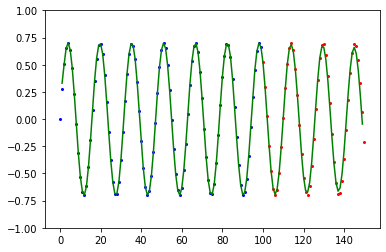

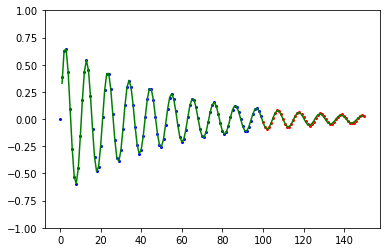

215800 4.556726849387558e-05 0.05511446278070739


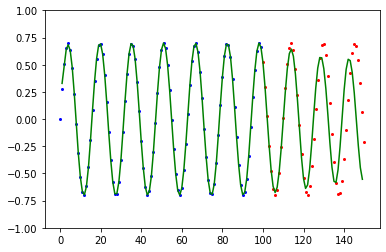

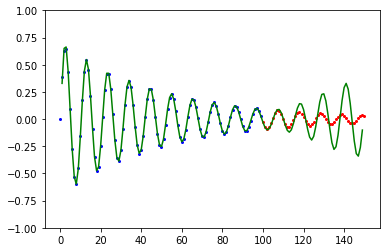

225200 5.4731216609577634e-05 0.2329720702780894


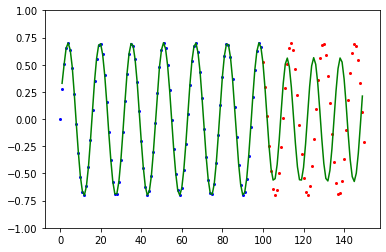

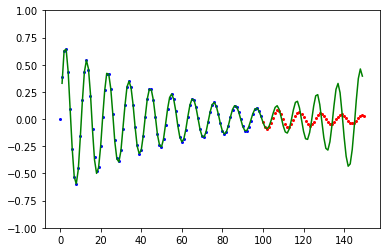

230300 4.4918238088680755e-05 0.16010666248691685


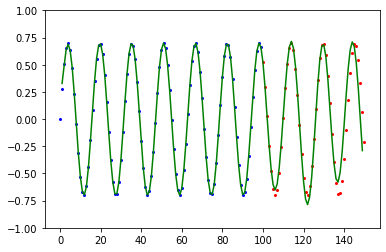

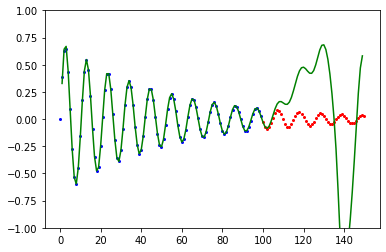

235100 6.195695984759348e-05 0.17376585332521952


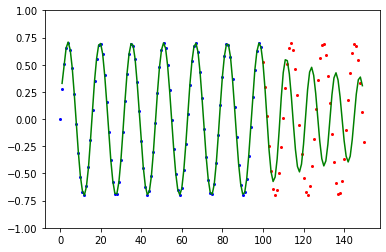

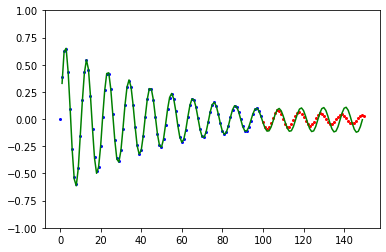

242600 3.480560133714298e-05 0.01197650208737763


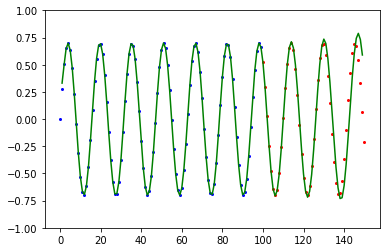

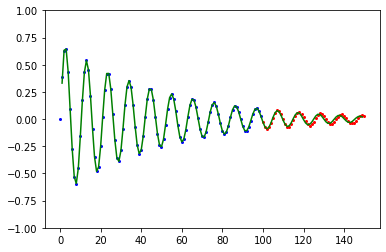

250200 3.5137097133162244e-05 0.18161619419863076


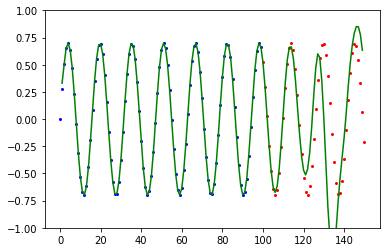

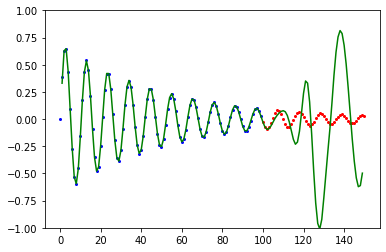

256400 3.9306341975515694e-05 0.03099113018644887


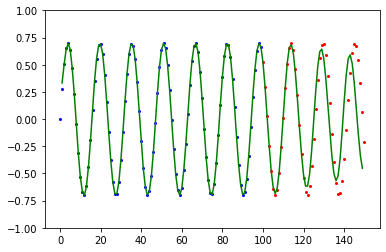

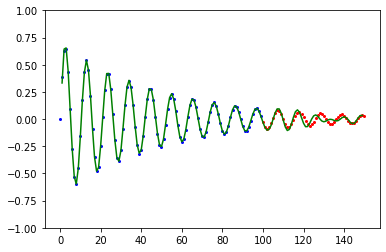

262100 3.9709083993651934e-05 0.0011733684690884035


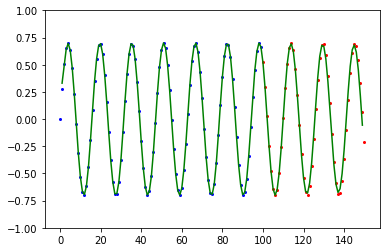

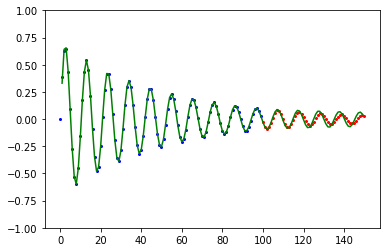

265600 0.01030394761011875 1.0256222379082822


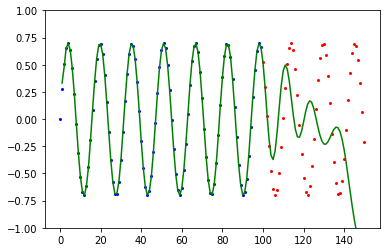

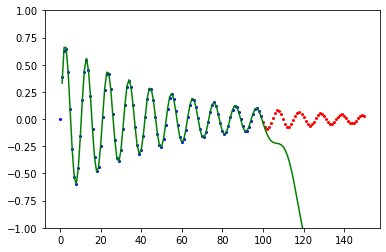

270500 4.018858524907078e-05 0.03752287238675529


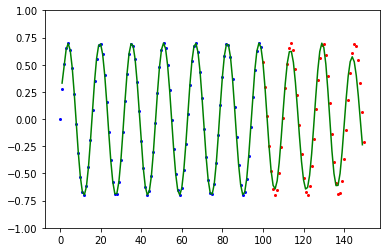

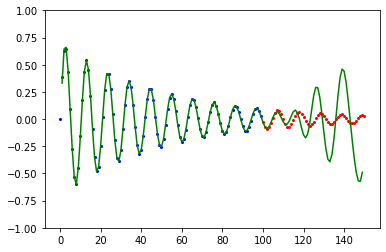

279700 3.511930159016588e-05 0.8835347912698993


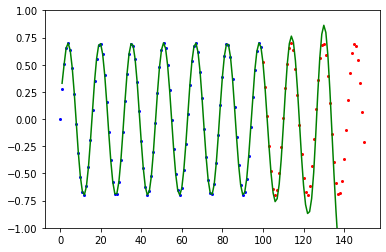

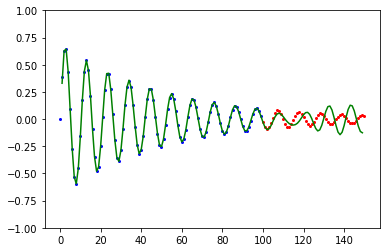

281600 0.033437047361412404 0.15829047395140755


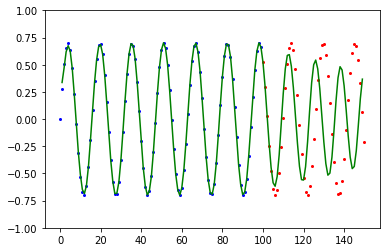

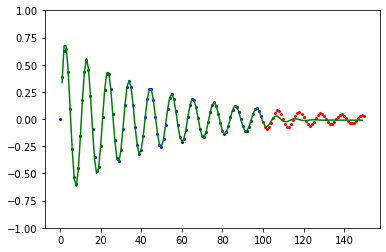

285100 0.08227952648247053 0.14084508626330974


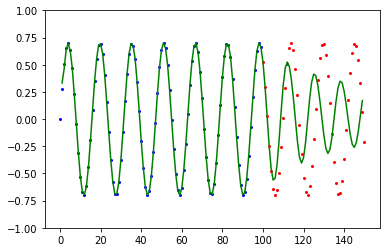

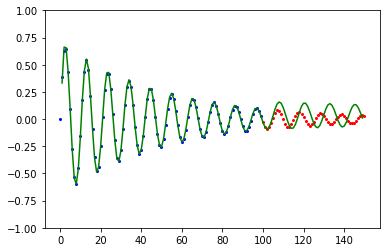

289600 0.0006703626365896121 0.17841515175024486


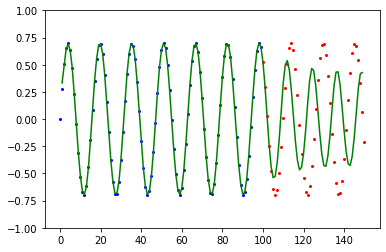

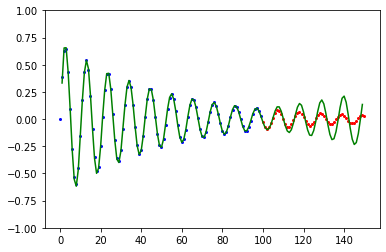

301700 3.4197580123162166e-05 0.007066597271744716


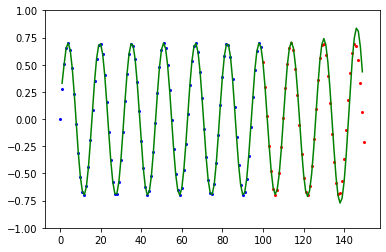

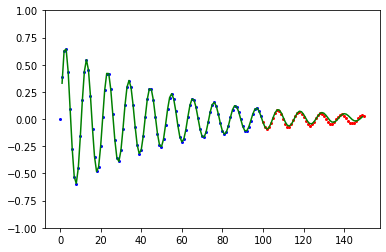

307900 3.584589681498299e-05 0.005345286824740971


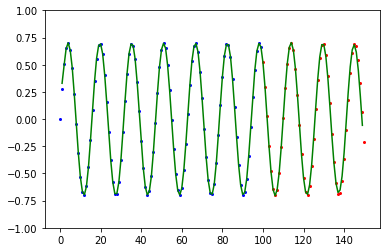

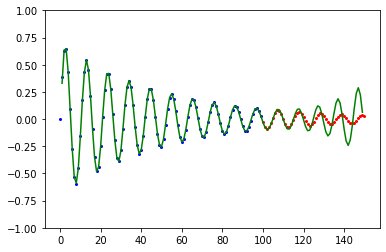

319000 3.9983685254079866e-05 0.04967009194032695


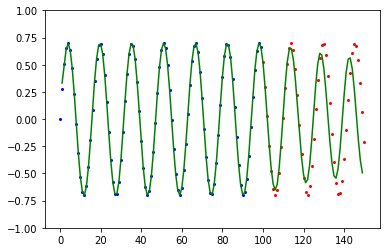

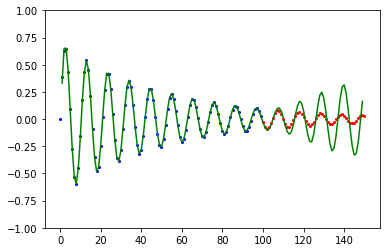

326200 8.538147696679237e-05 0.03942013691713825


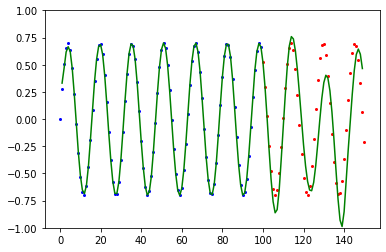

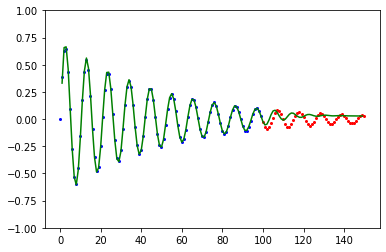

333700 6.189883011544095e-05 0.13336116383469326


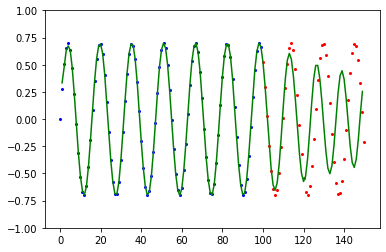

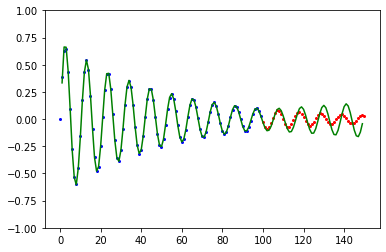

348100 3.518852491240287e-05 0.01948354599826056


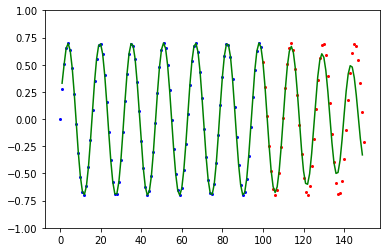

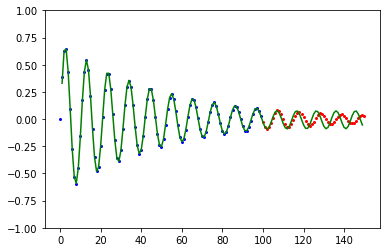

354100 5.3077506201392056e-05 0.5532886054774258


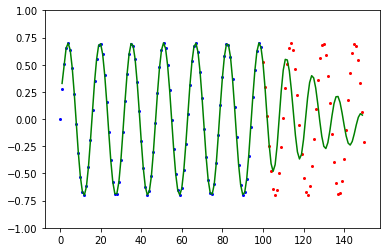

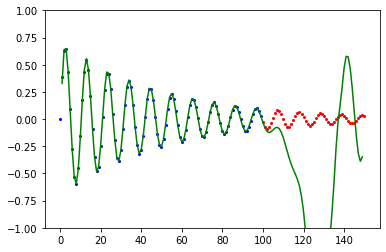

361600 4.171049959302187e-05 0.15668464083570321


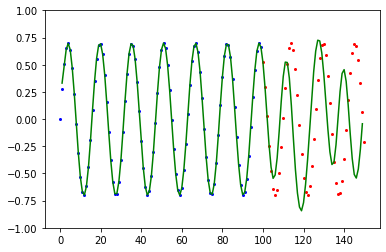

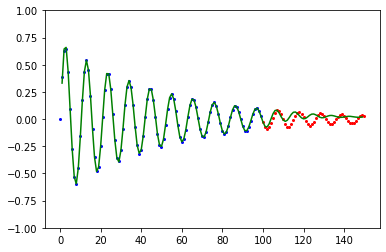

369400 4.2702354344933785e-05 0.13142068254066774


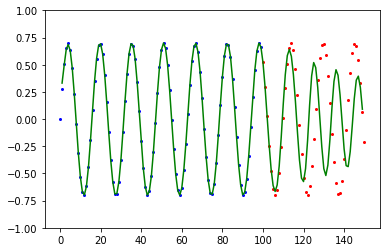

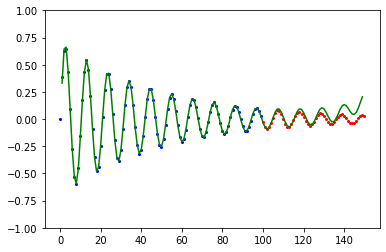

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.15957345, dtype=float64)

In [35]:
len(test_result)

50